In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import LineCollection
from scipy import stats
import seaborn as sns
from collections import Counter
import statsmodels.api as sm
import statsmodels.formula.api as smf
sns.set_context("notebook", rc={"font.family": 'sans-serif',
                                'font.sans-serif': 'Helvetica'})

plt.rcParams['font.sans-serif'] = ['Helvetica']
sns.set(font_scale=2) 
sns.set_style("white")
# sns.set_style("ticks")
%matplotlib inline

# Helper function

In [2]:
def paired_line(data, lines, column1, cond1_ls, x_axis):
    plt.rcParams["figure.figsize"] = (3,10)
    ax = sns.pointplot(x=cond1_ls, y=column1, data=data)
    sns.despine()
    

def non_unique(l):
    def low(x):
        return x.lower() if isinstance(x, str) else x
    c = Counter(map(low, l))
    return [x for x in l if c[low(x)] > 1]

# AgRP chemogenetics

In [3]:
data = pd.read_csv('chemogenetics.csv', encoding='cp1252')
data = data[data['receptor'].isin(['Gq', 'mCher'])]
data_pre = data.groupby(['receptor', 'state_D2']).size().reset_index(name='n')
data_post = data.groupby(['receptor', 'state_after']).size().reset_index(name='n')
#data_D2 = data.groupby(['receptor', 'state_D2']).size().reset_index(name='n')
data_pre.loc[-1] = ['Gq', 'Agg+', 0]
data_pre.loc[-2] = ['mCher', 'Agg+', 0]

data_pre = data_pre.rename(columns = {'state_D2': 'state'})
data_post = data_post.rename(columns = {'state_after': 'state'})

data_t = pd.concat([data_pre, data_post], keys = ['CNO-', 'CNO+'])
data_t.reset_index(inplace = True)
data_t.loc[-1] = ['CNO+', 2,'mCher', 'Agg+', 0]

data_count = data.groupby(['receptor']).size().reset_index(name = 'count')
data_per = data_t.merge(data_count, how = 'outer', on = 'receptor')
data_per['percentage'] = data_per['n'] / data_per['count'] *100

## food intake

In [4]:
Gq_dat = data[data['receptor'] == 'Gq']
stat, p = stats.ttest_rel(Gq_dat['food_consumption_null'],
                           Gq_dat['food_consumption_CNO'])
print(p)

9.698631809291145e-05


In [5]:
d1 = data_per[(data_per['receptor'] == 'Gq') & (data_per['state'] == 'Agg+')].reset_index()
d2 = data_per[(data_per['receptor'] == 'Gq') & (data_per['state'] == 'Agg-')].reset_index()
d = np.array([[d1.n[0], d2.n[0]],
      [d1.n[1], d2.n[1]]])

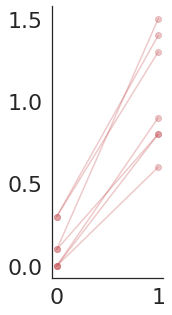

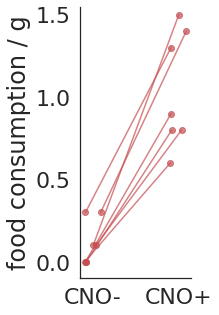

In [6]:
fig = plt.figure(figsize = (2,5))
# sns.set(font_scale=1.5)
# sns.set_style("white", {'font.family':'serif'})
x_axis = ['CNO-', 'CNO+']
jitter_x = []

# Gq food consumption with and without CNO
lines_Gq = data[data['receptor'] == 'Gq'][['food_consumption_null', 'food_consumption_CNO']].values.tolist()
    

for i in range(len(lines_Gq)):
    plt.plot(lines_Gq[i], 'ro-', alpha = 0.3)
    ax = plt.gca()
    lines = ax.lines
    jitter_x.append(lines[i].get_xdata() + np.random.uniform(-0.1, 0.1))
    
sns.despine()

fig = plt.figure(figsize = (2,5))
for i in range(len(lines_Gq)):
    plt.plot(jitter_x[i], lines_Gq[i], 'ro-', alpha = 0.7)
    ax = plt.gca()

    
sns.despine()
jitter_x2 = []
plt.ylabel('food consumption / g')
#plt.title('Gq food consumption')
ax.set_ylim([-0.1, 1.55])
ax.set_xticks(np.arange(2), ('CNO-', 'CNO+'))
plt.savefig('Gq_food.jpg', dpi=300,bbox_inches='tight')

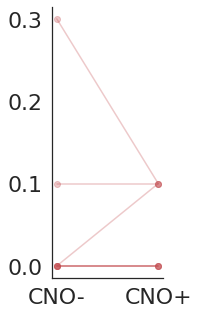

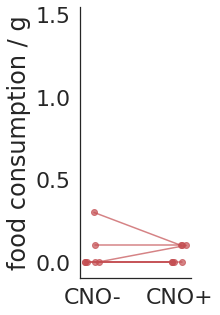

In [7]:
# mCher food consumption with and without CNO
fig2 = plt.figure(figsize = (2,5))
lines_mcher = data[data['receptor'] == 'mCher'][['food_consumption_null', 'food_consumption_CNO']].values.tolist()


for i in range(len(lines_mcher)):
    plt.plot(x_axis, lines_mcher[i], 'ro-', alpha = 0.3)
    jitter_x2.append(lines[i].get_xdata() + np.random.uniform(-0.1, 0.1))

sns.despine()
fig = plt.figure(figsize = (2,5))
for i in range(len(lines_mcher)):
    plt.plot(jitter_x2[i], lines_mcher[i], 'ro-', alpha = 0.7)

sns.despine()
ax = plt.gca()
ax.set_ylim([-0.1, 1.55])
ax.set_xticks(np.arange(2), ('CNO-', 'CNO+'))

plt.ylabel('food consumption / g')
#plt.title('mCher food consumption')
plt.savefig('mCher_food.jpg', dpi=300,bbox_inches='tight')

## parental behaviour

In [8]:
_, p  =  stats.fisher_exact(d)
print(p)

0.004662004662004674


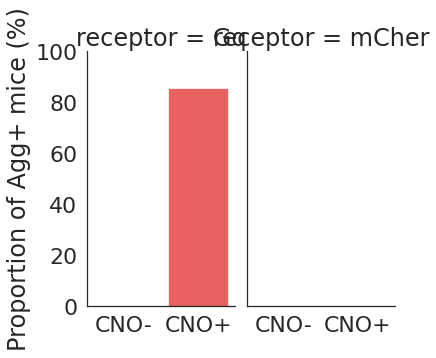

In [9]:
data_per = data_per[data_per['receptor'].isin(['Gq', 'mCher'])]

# sns.set(rc={'figure.figsize':(8,5)}, font_scale = 1.3)
# sns.set_style("white", {'font.family':'serif'})
g = sns.catplot(x = 'level_0',
                y = 'percentage',
                col = 'receptor',
                data = data_per[data_per['state'] == 'Agg+'],
                kind = 'bar',
                alpha = 0.7, 
                palette = ['red'],
                aspect = 2.2/4)

g.set(xlabel = None)
g.set(ylabel = 'Proportion of Agg+ mice (%)')
plt.ylim([0,100])
sns.despine()
plt.savefig('chemogenetics.jpg', dpi=300,bbox_inches='tight')

# optogenetics

## food intake

In [22]:
df = pd.read_csv('optogenetics.csv')
conditions = df.pup_light_cond.dropna().unique()

In [4]:
food_df = df[(df.pup_light_cond.isin(conditions[-2:])) & (df.histology_validation !='invalid')&(df.implantation_region == 'MPOA')]
food_df["status"] = pd.to_numeric(food_df.status)
food_df["parental_status"] = pd.to_numeric(food_df.parental_status)
food_df.pup_light_cond = pd.Categorical(food_df.pup_light_cond, 
                          categories=conditions[-2:],
                          ordered=True)

/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until
/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/pandas/core/generic.py:5516: SettingWithCopyWarning: 
A value is trying to be s

In [5]:
# compute stats for food intake
stat, p = stats.ttest_rel(food_df[food_df.pup_light_cond == '60_lighton_food'].status,
                          food_df[food_df.pup_light_cond == '60_post_food'].status)
print(p)

0.009708813429850532


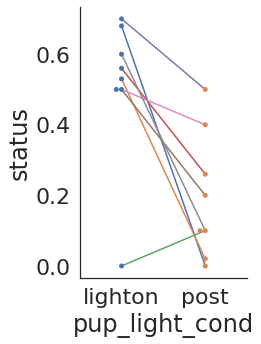

In [6]:
plt.subplots(figsize = [3,5])
sns.swarmplot(x = 'pup_light_cond', y = 'status', data = food_df)
sns.lineplot(x="pup_light_cond", y="status", hue='mice_ID', data=food_df,
             estimator=None, legend=False)
locs, labels = plt.xticks()
plt.xticks(locs,(['lighton', 'post']))
sns.despine()

In [7]:
## food intake latency and aggressive behaviour latency correlation
corr = pd.merge(df[df.pup_light_cond == '60_lighton_food'], df[df.pup_light_cond== '30_lighton'], on = 'mice_ID')
corr["status_x"] = pd.to_numeric(corr.status_x)
corr["parental_status_y"] = pd.to_numeric(corr.parental_status_y)
corr["parental_status_x"] = pd.to_numeric(corr.parental_status_x)
corr = corr[corr.histology_validation_x != 'invalid']

Text(0, 0.5, 'food consumption latency')

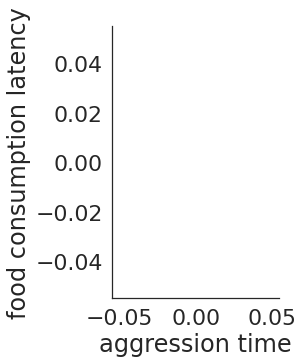

In [8]:
plt.subplots(figsize = [3,5])
sns.scatterplot(x = 'status_x',
            y = 'parental_status_y',
            data = corr)
sns.despine()
plt.xlabel('aggression time')
plt.ylabel('food consumption latency')

In [9]:
#test stats relationship
model = smf.ols('parental_status_y ~ status_x', data=corr).fit()
model.summary()

ValueError: zero-size array to reduction operation maximum which has no identity

Text(0, 0.5, 'food consumption latency')

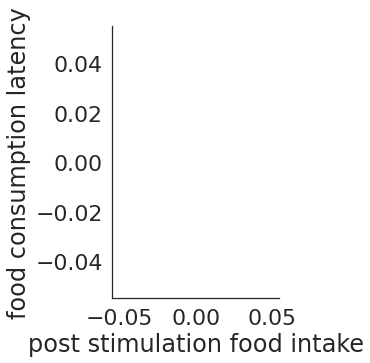

In [10]:
plt.subplots(figsize = [3,5])
sns.regplot(x = 'status',
            y = 'parental_status',
            data = food_df)
sns.despine()
plt.xlabel('post stimulation food intake')
plt.ylabel('food consumption latency')

## parental behaviour

In [14]:
props

,pup_light_cond,status,count,n,props
0,15_lighton,Agg+,0,6,0.000000
1,15_lighton,Agg-,5,6,0.833333
2,30_lightoff,Agg+,0,8,0.000000
3,30_lightoff,Agg-,8,8,1.000000
4,30_lighton,Agg+,4,10,0.400000
5,30_lighton,Agg-,6,10,0.600000
6,instantaneous_off,Agg+,0,4,0.000000
7,instantaneous_off,Agg-,2,4,0.500000
8,instantaneous_on,Agg+,0,4,0.000000
9,instantaneous_on,Agg-,2,4,0.500000


In [23]:
par_df = df[(df.pup_light_cond.isin(conditions[:6]))& (df.histology_validation == 'valid')]
count = par_df.groupby(['pup_light_cond', 'status']).size().unstack(fill_value=0).stack().reset_index(name = 'count')
ns = par_df.groupby(['pup_light_cond']).size().reset_index(name='n')
props = pd.merge(count, ns, on = 'pup_light_cond')
props['props'] = props['count'] / props['n']
props.pup_light_cond = pd.Categorical(props.pup_light_cond, 
                      categories=conditions[:6],
                      ordered=True)

In [24]:
table_df = par_df[(par_df.implantation_region == 'MPOA') & (par_df.pup_light_cond.isin(['30_lighton', '30_lightoff']))]
table = pd.crosstab(table_df.pup_light_cond, table_df.status)
chi, p, dof, expected = stats.chi2_contingency(table)
print(table, p)

status          Agg+  Agg-
pup_light_cond            
30_lightoff        0     4
30_lighton         4     0 0.033894853524689295


/home/tochenan/.conda/envs/dlc-ubuntu-CPU/lib/python3.7/site-packages/pandas/core/generic.py:5516: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[name] = value


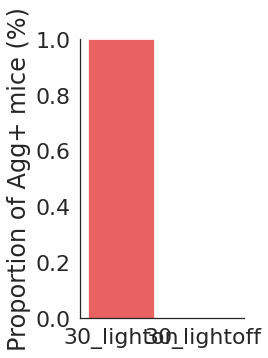

In [25]:
# plot_cond = ['instantaneous_on', '15_lighton', '30_lighton', '30_lightoff']
plot_cond = [ '30_lighton', '30_lightoff']

plot_df = props[(props.status == 'Agg+')& (props.pup_light_cond.isin(plot_cond))]
plot_df.pup_light_cond = pd.Categorical(plot_df.pup_light_cond, 
                      categories=plot_cond,
                      ordered=True)
# sns.set(rc={'figure.figsize':(10,5)}, font_scale = 1.3)
# sns.set_style("white")
g = sns.catplot(x = 'pup_light_cond',
                y = 'props',
                data = plot_df,
                kind = 'bar',
                alpha = 0.7, 
                palette = ['red'],
                aspect = 4.5/6)

g.set(xlabel = None)
g.set(ylabel = 'Proportion of Agg+ mice (%)')
plt.ylim([0,1])
sns.despine()
plt.savefig('opto_parental.jpg', dpi=300,bbox_inches='tight')